Variance explained by first 3 PCs:
PC1: 20.67%
PC2: 16.85%
PC3: 8.03%

Total variance explained by first 3 PCs: 45.55%

Number of PCs needed to capture at least 85% of the variance: 17


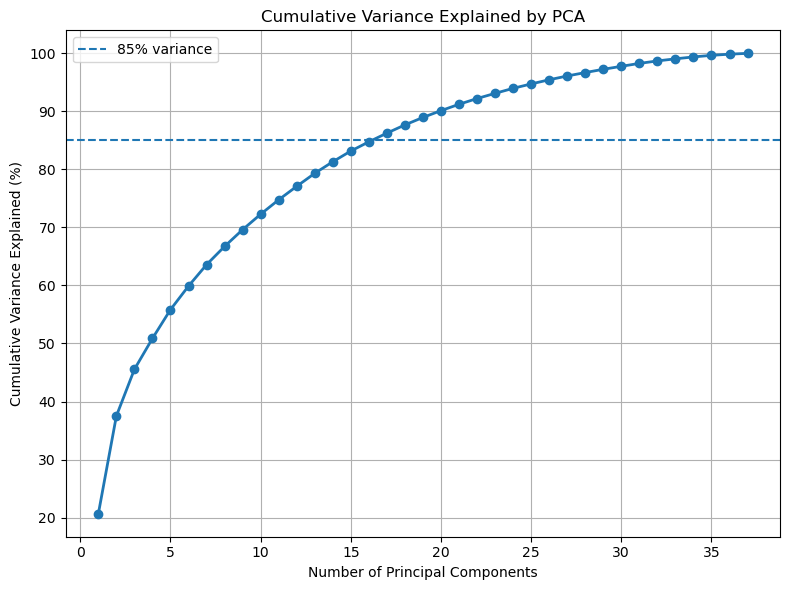

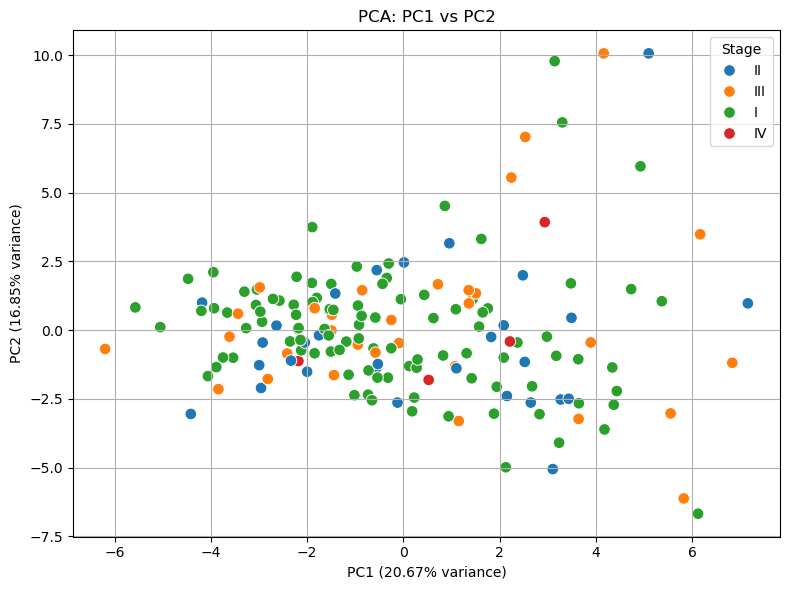

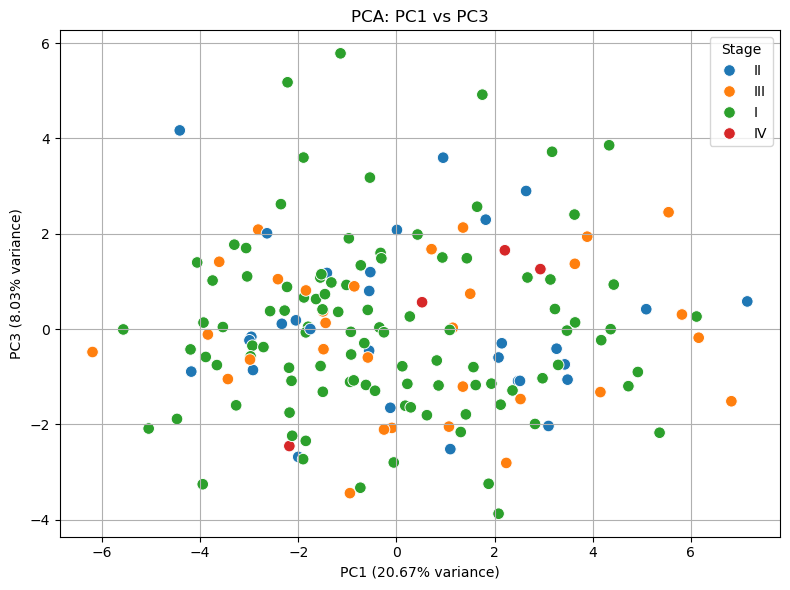

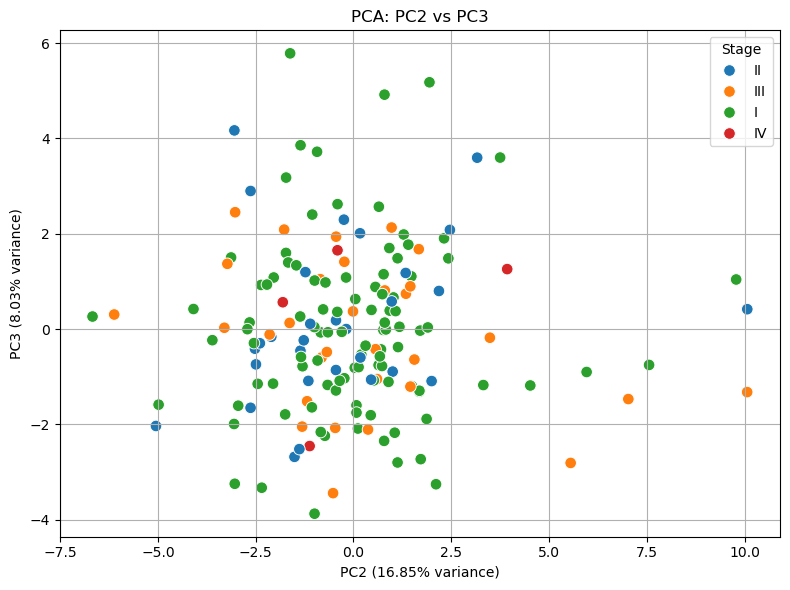

PC1 loading scores:
CDC20      0.322759
PLK1       0.297797
E2F1       0.291204
CDC25A     0.287058
CHEK2      0.283431
CCNF       0.277736
CDK1       0.240928
PCNA       0.201607
HDAC1      0.194753
CDK16      0.185452
CDKN2D     0.155204
GADD45A    0.148323
FZR1       0.142126
S100A9     0.138611
CDK4       0.137740
PTMA       0.119346
CDK2       0.114403
CDKN1A     0.104107
CDK5R2     0.087427
TFDP1      0.060631
CDK10      0.050858
CDKN1C     0.033567
CCNA1      0.022852
SERTAD1    0.013978
CDKN2B    -0.000476
MDM2      -0.012176
WEE1      -0.025344
CDK7      -0.029338
CUL4A     -0.034887
CCND2     -0.040588
CDC27     -0.072780
PLAGL1    -0.079609
NBN       -0.109431
CCND1     -0.119807
EP300     -0.186069
CUL5      -0.186311
SMAD4     -0.203107
dtype: float64


In [207]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Project: BME 6006 Final Project 
Author: Allie Sack+Ella Bouker
Due Date: 10/14/26
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import csv
import array

#data source: https://www.cbioportal.org/study/summary?id=luad_oncosg_2020

#%% Organize the matrix
# Read the clinical data file
data_clinical_patient = pd.read_excel('data_clinical_patient_6006_project.xlsx')

# Remove patients whose ID starts with "B"
data_clinical_patient = data_clinical_patient[
    ~data_clinical_patient['#Patient identifier'].astype(str).str.startswith('B')
]

# Read the mRNA gene-expression Excel file
# nrows=101 means only the first 101 rows are read (the first row contains the column names so this gives 100 genes)
# I truncated at 100 genes because it was taking too long for python to go through all the genes

# EEB - need all genes to then filter out the ones I want once I've populated the dataframe so no truncation
'''
data_mrna_seq_zscores = pd.read_excel(
    'data_mrna_seq_v2_rsem_zscores_ref_all_samples_6006_project.xlsx',
    nrows=501
)
'''

data_mrna_seq_zscores = pd.read_excel(
    'data_mrna_seq_v2_rsem_zscores_ref_all_samples_6006_project.xlsx',
)


## Transpose mRNA dataframe ##
#need to do this because want sample ID as rows not genes for analysis

# First column in original datafram contains the gene/sample identifier
mrna_seq_transposed = data_mrna_seq_zscores.set_index( #tells pandas to use the first column (the gene IDs) as the row index rather than treating it as a variable
    data_mrna_seq_zscores.columns[0] # this gives the name of the first column which is the gene identifiers 
).T #.T transposes the data

# Turn the sample ID (currently the index) into a column
mrna_seq_transposed = mrna_seq_transposed.reset_index()

# Rename the sample ID column
mrna_seq_transposed = mrna_seq_transposed.rename(
    columns={'index': 'Patient ID'}
)

## Get sample ID and detailed cancer type from the clinical dataframe ##
cancer_type = data_clinical_patient[
    ['#Patient identifier', 'Stage']
]

## Match sample IDs and add histology abbreviation for each sample ##
#the samples aren't in the same order across files so need to make sure the correct histological abbreviation is matched with the correct sample and RNA data
mrna_seq_transposed = mrna_seq_transposed.merge(
    cancer_type,
    left_on='Patient ID',  # Column in the mRNA dataframe containing the sample ID
    right_on='#Patient identifier', # Column in the clinical dataframe containing the sample ID
    how='left'     
    # Keep all samples from the mRNA dataframe and add the matching clinical information when possible
)

# Remove the #Sample Identifier column because now redundant - same info already in Sample ID
mrna_seq_final = mrna_seq_transposed.drop(
    columns=['#Patient identifier']
)

# Remove patients with no Stage information
mrna_seq_final = mrna_seq_final.dropna(subset=['Stage'])

## Move detailed cancer type to the far left ##

cols = mrna_seq_final.columns.tolist() # Get a list containing all of the dataframe's column names
cols.insert(0, cols.pop(cols.index('Stage'))) 
# Find the position of "Cancer Type Detailed", remove it from its current position, insert it at position 0 (first column)

## Reorder the dataframe using the new column order where its Cancer Type Detailed then Sample ID then all of the genes
mrna_seq_final = mrna_seq_final[cols]

# ---------------------------------------------------------------------------------------------------------------------------------------
# EEB - here is the section where we will filter the big dataset (mrna_seq_final) for just our genes of interest before running further analyses

# Workflow 
# 1) find manuscript with relevant genes 
# 2) dump genes into Claude and ask it to compare against genesfromdataset.csv, then return a list of conserved genes (genes that are listed in both) to plug in below as df_GOIx
# ask it to return the list in this format: [["gene1", "gene2", ... "genen"]]
# then take this list and append it: df_GOIx = mrna_seq_final + list and change line 137 to the new number (x)
# make sure to update DOIs to prevent double checking the same sets

# mrna_seq_final DF Format
# columns L to R: Stage, Patient ID, genes 

# DOIs of genes tested
#df_GOI1 = http://dx.doi.org/10.1097/MD.0000000000023052 
#df_GOI2 = ?
#df_GOI3 = 10.7717/peerj.7313 
#df_GOI4 = http://doi.org/10.7717/peerj.17746
#df_GOI5 = https://doi.org/10.3389/fonc.2019.01314  
#df_GOI6 =  https://doi.org/10.1002/cam4.3240
#df_GOI7 = https://doi.org/10.3389/fimmu.2021.752643
#df_GOI8 = https://doi.org/10.3389/fcell.2021.651406
#df_GOI9 = https://doi.org/10.1007/s00251-020-01189-z
#df_GOI10 = https://doi.org/10.1016/j.jtho.2019.07.031
#df_GOI11 = https://doi.org/10.1158/1078-0432.CCR-08-0544
#df_GOI12 = 10.4161/cbt.2.3.399

# Genes that did not cluster
df_GOI1 = mrna_seq_final[["Stage", "Patient ID", "ZWINT", "RFC4", "CCNB2", "NUSAP1", "MELK", "PRC1", "RRM2", "GINS2", "KIF18B", "TOP2A", "TPX2", "CDC20", "CEP55", "GINS1", "CENPU", "BUB1B", "CDK1"]]
df_GOI2 = mrna_seq_final[["Stage", "Patient ID", "SPP1", "OCIAD2", "ETV4", "COL10A1", "PROM2", "MMP11", "UBE2T", "ABCC3", "BAIAP2L1", "FABP4", "STX11", "CAV1", "FHL1", "TEK", "AGER", "FMO2", "CRYAB","GRK5", "TMEM100"]]
df_GOI3 = mrna_seq_final[["Stage", "Patient ID", "COL11A1", "TFAP2A", "SPP1", "UBE2C", "SERPINB5", "DSP", "TPX2", "IGF2BP3", "SULF1", "S100A2", "GINS1",  "COL17A1", "CCNB2", "HIST1H2BD","SRD5A1", "EZH2"]]
df_GOI4 = mrna_seq_final[["COL11A1", "TFAP2A", "SPP1", "UBE2C", "SERPINB5", "DSP", "TPX2", "IGF2BP3", "SULF1", "S100A2", "GINS1", "COL17A1", "CCNB2", "HIST1H2BD", "SRD5A1", "EZH2", "ALDH3B2", "CCNE1", "MMP11", "CDKN3", "CDK1", "CENPF", "COL10A1", "PTTG1", "SLC9A3R1", "KIF2C", "CA12", "LAD1", "CCNB1", "ZWINT", "ADAMDEC1", "FOXM1", "APOBEC3B", "CYP24A1", "MELK", "FAP", "SCG5", "CDC20", "KIF11", "PMAIP1", "LRRC15", "TTK", "PLOD2", "BUB1B", "NFE2L3", "SORD", "PLK1", "SPAG5", "GCLC", "POSTN", "DTYMK", "CKS1B", "ATP2A2", "CKS2", "AIM2", "SLC5A3", "IRF6", "TK1", "STIL", "KIF14", "UMPS", "PAICS", "ST14", "TOP2A", "PYCR1", "FUT3", "FEN1", "CDC6", "KNTC1", "PCNA", "ESPL1", "USP46", "KIFC1", "NCAPH", "CPOX", "NPM3", "TMF1", "KIF2A", "BDH1", "TFAP2C", "SLC35A2", "GGCT", "FABP4", "WIF1", "CLDN5", "AGER", "C7", "FHL1", "ZBTB16", "MFAP4", "DES", "CLIC5", "ADIRF", "PTX3", "VWF", "GPX3", "TNNC1", "ADH1B", "AGTR1", "TCF21", "CHRDL1", "SGCA", "FMO2", "IGFBP6", "ABCA8", "NRGN", "LDB2", "CDH5", "FCN1", "TTN", "AQP1", "TEK", "LRRN3", "RAMP2", "PPBP", "PTPRB", "STARD8", "EDNRB", "CA4", "ABLIM3", "GPM6A", "CA3", "AQP4", "LPL", "FCN3", "C8B", "ACKR1", "BMP5", "CBFA2T3", "AOC3", "GPM6B", "DLC1", "GPD1", "CFD", "CAV1", "TGFBR3", "SYNM", "SRPX", "TMOD1", "AOX1", "FAM107A", "GNG11", "CSF3", "SELP", "LMO7", "MMRN1", "CD93", "NR4A3", "ANXA3", "RECK", "ADARB1", "ACADL", "FXYD1", "OLFML1", "EMP2", "FBLN5", "SELE", "ADAMTSL3", "FEZ1", "ENG", "RASGRF1", "ID4", "SVEP1", "ITGA9", "GJA4", "LDLR", "MYRF", "SMAD6", "VNN2", "BCHE", "LILRB2", "WISP2", "COX7A1", "SLC6A4", "SPOCK2", "NEDD9", "ADRB2", "CLC", "HOXA5", "C14orf132", "TGFBR2", "ACE", "MYH10", "SCEL", "GATA2", "TIE1", "LRRC32", "CDO1", "FOXF1", "SLIT2", "CD34", "GPC3", "STX11", "SPARCL1", "DPYSL2", "FBLN1", "TBX2", "BMX", "LMO2", "ANGPT1", "ABCA6", "ITM2A", "SGCE", "LTBP4", "ALOX5AP", "DST", "KLF9", "FAM189A2", "TAL1", "MAOB", "GYPC", "MS4A2", "AGTR2", "ABLIM1", "F8", "MAL", "GRK5", "CAV2", "S1PR1", "THBD", "EFEMP1", "CH25H", "G0S2", "KDR", "MYH11", "FLI1", "HLF", "P2RY14", "VSIG4", "MMP19", "MME", "SOCS2", "TMEM47", "KANK3", "CALCRL", "RAMP3", "HBEGF", "KIAA0040", "RASSF2", "NOTCH4", "KLF4", "RGS2", "PRKCZ", "HEG1", "WFS1", "PROS1", "GMFG", "PPP1R15A", "IL3RA", "CA2", "PLCE1", "FRY", "CREM", "CDKN1C", "CRIP2", "FSTL3", "TACC1", "PODXL", "MACF1", "PMP22", "CBX7", "FERMT2", "TYRP1", "ICAM2", "RPS6KA2"]]
df_GOI5 = mrna_seq_final[["PSMD11", "PPIA", "MIF", "BMP5", "DKK1", "PDGFB", "ANGPTL4", "IL1R2", "THRB", "LTBR", "TNFRSF17", "IL20RB", "MC1R"]]
df_GOI6 = mrna_seq_final[["ARNTL2", "ECT2", "PPIA", "TUBA4A"]] # best so far but still no major clusters, if using, need to take out all PC3 related analyses below
df_GOI7 = mrna_seq_final[["AICDA", "BLK", "BTN1A1", "CCL25", "CCR9", "CD1B", "CD70", "CLEC12B", "CLEC4D", "CLEC6A", "CLECL1", "CLNK", "CNR2", "COL25A1", "CR1L", "CTLA4", "FASLG", "FCER2", "FCRL3", "GPR18", "HLA-A", "HLA-B", "HLA-C", "HLA-DMA", "HLA-DMB", "HLA-DOA", "HLA-DOB", "HLA-DPA1", "HLA-DPB1", "HLA-DQA1", "HLA-DQA2", "HLA-DQB1", "HLA-DQB2", "HLA-DRA", "HLA-DRB1", "HLA-DRB5", "HLA-E", "HLA-F", "HLA-G", "IFNG", "IL22RA2", "IL27", "IL9R", "INHA", "KIF1A", "KIR2DL4", "KLRC1", "KLRC2", "LILRA4", "LTA", "NCR1", "NCR3", "PAX5", "PDCD1", "TMIGD2", "TNFRSF13B", "TRAT1", "XCL2"]]
df_GOI8 = mrna_seq_final[["ARF1", "ALDOA", "FKBP2", "NDUFS5", "NDUFC1", "COX7A2", "LNX1", "BTBD6"]] # second best
df_GOI9 = mrna_seq_final[["ATAD5", "CYP4F3", "CYP4F12", "ESPNL", "FXYD2", "GPX2", "NLGN4Y", "SERPINC1"]]
df_GOI10 = mrna_seq_final[[ "EGFR", "ERBB2", "NRAS", "BRAF", "TP53"]]
df_GOI11 = mrna_seq_final[[ "ERBB3", "LCK", "RND3"]] # not tested -> need to take out PC3 to test
df_GOI12 = mrna_seq_final[["CCNE1", "CCNB1", "PLK1", "CCNA1", "PTMA", "PCNA", "CDC25A", "CDK4", "HDAC1", "MDM2", "CCND1", "E2F1", "CDK2", "CCND2", "CDKN2B", "S100A9", "CHEK2", "CDKN1A", "SMAD4", "CDKN2D", "CDC20", "CDK1", "CCNF", "EP300", "CDK7", "TFDP1", "CUL4A", "NBN", "CDK16", "CDC27", "FZR1", "CDK10", "CUL5", "PLAGL1", "WEE1", "CDK5R2", "GADD45A", "CDKN1C", "SERTAD1"]]

# In progress 

# Test here
df_GOIF = df_GOI12 # just change this line

# Removing patient ID and stage 
df_GOIF = df_GOIF.drop(df_GOIF.columns[[0, 1]], axis=1)

#----------------------------------------------------------------------------------------------------
# EEB - unneccesary right now 
## filter out the specific cancer types I want to analyze ##
#I did this because having all types was way too much data to reasonably analyze for this
#I thought it'd be interesting to see mRNA changes for the same camcer type across different organs
#pancan_mrna_filtered = pancan_mrna_final[
    #pancan_mrna_final['Cancer Type Detailed'].isin([
     #   'Pancreatic Adenocarcinoma',
     #   'Prostate Adenocarcinoma',
     #   'Colorectal Adenocarcinoma'
  #  ])
#]
#----------------------------------------------------------------------------------------------------
#%% Create clustered heatmap

''' 
# EEB - not needed rn
# Create row labels containing Sample ID and Cancer Type so each sample can be identified on the heatmap
row_labels = (
    df_GOIF['Patient ID'] 
    + ' , ' # separate sample ID and cancer type with comma
    + df_GOIF['Stage']
)
# EEB - taken care of up above
# Remove Sample ID and Cancer Type because they are identifiers not gene-expression variables that should be used for clustering
data_matrix = df_GOIF.drop(
    columns=['Stage', 'Patient ID'], axis=1
)
'''
# Remove any gene that contains a NaN value
data_matrix = df_GOIF.dropna(axis=1)

#print(data_matrix.head())
#----------------------------------------------------------------------------------------------------
# EEB - don't need a heatmap right now, just going for PCA to minimize processing time

# Create a clustered heatmap using the gene-expression data
#cluster1 = sns.clustermap(
    #data_matrix,
    #cmap='bwr', # Use a blue-white-red color scale for the gene-expression values
    #center=0,  # Center the color scale at 0 because the data are z-scores
    #figsize=(20, 20), # Set the size of the heatmap
    #metric='euclidean', # Use Euclidean distance to measure differences between samples/genes
    #method='complete',  # Use complete linkage to determine how clusters are formed
    #row_cluster=True,  # Cluster the samples (rows)
    #col_cluster=True, # Cluster the genes (columns)
    #yticklabels=row_labels # Label each row with its Sample ID and Cancer Type
#)

# display the heatmap
#plt.show()

#----------------------------------------------------------------------------------------------------

#%% perform PCA

pca = PCA() #create a pca model
# Perform PCA on the gene-expression data and transform the data
coefficients = pca.fit_transform(data_matrix) # "coefficients" contains the PCA scores for each sample

# Calculate the percentage of total variance explained by each PC
explained = pca.explained_variance_ratio_ * 100

# Calculate the cumulative percentage of variance explained
cumulative_explained = np.cumsum(explained) # This adds the variance explained by each PC to the previous PCs

# Print variance explained by first 3 PCs
print("Variance explained by first 3 PCs:")
print(f"PC1: {explained[0]:.2f}%")
print(f"PC2: {explained[1]:.2f}%")
print(f"PC3: {explained[2]:.2f}%")       #PC3

print(f"\nTotal variance explained by first 3 PCs: "
      f"{cumulative_explained[2]:.2f}%")     # PC3

# Find the number of PCs needed to explain at least 85% of the variance
# np.argmax finds the first PC where cumulative variance reaches 85%
# +1 is needed because Python starts counting at 0
n_pcs_85 = np.argmax(cumulative_explained >= 85) + 1

# Print the number of PCs needed to reach 85% variance
print(f"\nNumber of PCs needed to capture at least 85% "
      f"of the variance: {n_pcs_85}")

## Plot cumulative variance explained ##

plt.figure(figsize=(8, 6))


plt.plot(
    np.arange(1, len(explained) + 1), # x-axis = number of PCs
    cumulative_explained, # y-axis = cumulative percentage of variance explained
    marker='o',
    linewidth=2
)

# Add a horizontal dashed line at 85%
# This makes it easy to see where the cumulative variance reaches 85%
plt.axhline(
    85,
    linestyle='--',
    linewidth=1.5,
    label='85% variance'
)

# Label axes
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained (%)')
plt.title('Cumulative Variance Explained by PCA')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Create dataframe containing PCA results ##
# Create a dataframe containing the PCA scores for each sample
# PC1, PC2, and PC3 are the transformed coordinates of each sample
pca_df = pd.DataFrame({
    'PC1': coefficients[:, 0],  # Get the PC1 score for every sample
    'PC2': coefficients[:, 1],  # Get the PC2 score for every sample
    'PC3': coefficients[:, 2],  # Get the PC3 score for every sample   
    'Stage': mrna_seq_final['Stage'].values,  # Add the cancer type for each sample
    # .values converts the pandas column into an array
    'Patient ID': mrna_seq_final['Patient ID'].values # Add the Sample ID for each sample
})

## PC1 vs PC2 ##

# Create a new figure for the PC1 vs PC2 plot
plt.figure(figsize=(8, 6))

# Create a scatter plot using the PCA scores
sns.scatterplot(
    data=pca_df, #using dataframe containing PCA results
    x='PC1', # PC1 scores on the x-axis
    y='PC2', # PC2 scores on the y-axis
    hue='Stage',  # Use different colors for the different cancer types
    s=70  # Set the size of each data point
)

plt.xlabel(f'PC1 ({explained[0]:.2f}% variance)') # Label the x-axis and show how much variance PC1 explains
plt.ylabel(f'PC2 ({explained[1]:.2f}% variance)') # Label the y-axis and show how much variance PC2 explains
plt.title('PCA: PC1 vs PC2')

plt.legend(title='Stage') #add legend for cancer types
plt.grid(True)
plt.tight_layout()
plt.show()

## PC1 vs PC3 ##
#PC3
# Create a new figure for the PC1 vs PC3 plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',  # PC1 scores on the x-axis
    y='PC3',  # PC1 scores on the x-axis
    hue='Stage', # Use different colors for the different cancer types
    s=70
)

plt.xlabel(f'PC1 ({explained[0]:.2f}% variance)') # Label the x-axis and show how much variance PC1 explains
plt.ylabel(f'PC3 ({explained[2]:.2f}% variance)') # Label the y-axis and show how much variance PC3 explains
plt.title('PCA: PC1 vs PC3')

plt.legend(title='Stage')
plt.grid(True)
plt.tight_layout()
plt.show()

## PC2 vs PC3 ##

# Create a new figure for the PC2 vs PC3 plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PC2', # PC2 scores on the x-axis
    y='PC3', # PC1 scores on the x-axis
    hue='Stage', # Use different colors for the different cancer types
    s=70
)

plt.xlabel(f'PC2 ({explained[1]:.2f}% variance)') # Label the x-axis and show how much variance PC2 explains
plt.ylabel(f'PC3 ({explained[2]:.2f}% variance)') # Label the y-axis and show how much variance PC3 explains
plt.title('PCA: PC2 vs PC3')

plt.legend(title='Stage')
plt.grid(True)
plt.tight_layout()
plt.show()

### loading scores ###
# Get the PC1 loading score for every gene
pc1_loadings = pd.Series(
    pca.components_[0], # pca.components_[0] contains the loading of each gene on PC1
    index=data_matrix.columns # Use the gene names as the index so each loading is associated with its corresponding gene
)

# Sort loading scores from highest to lowest loading
pc1_loadings_sorted = pc1_loadings.sort_values(ascending=False)

# Print the PC1 loading scores
print("PC1 loading scores:")
print(pc1_loadings_sorted)
